# Modeling (INSERT NAME HERE)

Using Nutrition Information to Classify Brand Tier (Premium Foods)

Mia Arnold - Jordan Blackman - Allen Ros

Shirley Marcos School of Engineering, University of San Diego

ADS-502 Applied Data Mining

# Goals

1. Data type transformation, remove features that would lead to overfitting, test train split, SMOTENC(nominal and continuous), Encoding, and Scaling.

2. Establish Baseline Model and evaluation metrics

3. Train initial models, tune hyperparameters (max leaf, minobservations, C for regularization), explore cost matrices, and explore bagging and boosting

4. Compare all models across multiple metrics beyond accuracy

Models to explore: Baseline (Majority Class), Naive Bayes, Decision Tree (CART, C5.0), kNN Classifier, Logistic Regression, SVC (Linear), SVC (RBF), SVC (Polynamial), SVC (Sigmoid), Random Forest Classifier (with bagging and boosting), XGBoost, Adaboost, and Neural Network.

# Data Type Transformation and Removing Overfitting Features

In [12]:
# import the necessary packages
import pandas as pd
import numpy as np

# Load the data
df = pd.read_csv("food_menu_nutrition_dataset.csv")

# log price, protein, and sugars to handle significant skew
df['log_price_usd_normalized'] = np.log1p(df['price_usd_normalized'])
df['log_protein_g'] = np.log1p(df['protein_g'])
df['log_sugars_g'] = np.log1p(df['sugars_g'])

# square root serving size, calories, fat, carbs, sodium to handle small skew
df['sqrt_serving_size_g'] = np.sqrt(df['serving_size_g'])
df['sqrt_calories'] = np.sqrt(df['calories'])
df['sqrt_total_fat_g'] = np.sqrt(df['total_fat_g'])
df['sqrt_total_carbs_g'] = np.sqrt(df['total_carbs_g'])
df['sqrt_sodium_mg'] = np.sqrt(df['sodium_mg'])

# flip average rating to handle left skew, units are flipped
reflect_constant = df['avg_rating'].max() + 1
df['trans_avg_rating'] = np.sqrt(reflect_constant - df['avg_rating'])

# is_bestseller is the only numerical variable left alone

# drop all original columns that were transformed
df = df.drop(columns=['price_usd_normalized', 'protein_g', 'sugars_g',
                      'serving_size_g', 'calories', 'total_fat_g',
                      'total_carbs_g', 'sodium_mg', 'avg_rating'])

# set up items that are nto being used for training models
items_to_drop = ['item_name', 'city', 'brand_name',
                 'brand_tier']

# get dependent and independent variables
Y = (df['brand_tier'] == 'premium').astype(int)
X = df.drop(columns=items_to_drop)

# view the data
df.head().T

,0,1,2,3,4
item_name,Veggie Sub,Waffles with Syrup,Grilled Chicken Salad,Waffles with Syrup,Chocolate Brownie
item_category,Sandwich,Dessert,Salad,Dessert,Dessert
item_subcategory,Veg,Veg,Non-Veg,Veg,Veg
brand_name,Five Guys,KFC,Domino's,Five Guys,Subway
brand_tier,mid,budget,budget,mid,budget
country,UK,USA,Canada,USA,USA
city,London,Austin,Toronto,Chicago,Chicago
city_tier,metro,tier-2,metro,metro,metro
is_bestseller,0,0,0,0,0
log_price_usd_normalized,2.267994,1.329724,1.912501,2.248129,1.332366


# Test Train Split

In [13]:
# test train split with random state and stratification
from sklearn.model_selection import train_test_split

X_train, X_test, Y_train, Y_test = train_test_split(
    X, Y, test_size=0.2, random_state=42, stratify=Y)

# SMOTE

In [14]:
# Oversample the minority class (Premium)
from imblearn.over_sampling import SMOTENC

cat_cols = df.select_dtypes(include=['object', 'category', 'string']).columns.drop(
    items_to_drop, errors='ignore').tolist()

cat_indices = [X_train.columns.get_loc(col) for col in cat_cols]

print("Before SMOTE")
print(Y_train.value_counts())

smote_nc = SMOTENC(categorical_features=cat_indices, random_state=42)
X_train, Y_train = smote_nc.fit_resample(X_train, Y_train)

print("After SMOTE:")
print(Y_train.value_counts())

Before SMOTE
brand_tier
0    5404
1     596
Name: count, dtype: int64
After SMOTE:
brand_tier
0    5404
1    5404
Name: count, dtype: int64


# Encoding

In [15]:
# encode variables
X_train_encoded = pd.get_dummies(X_train, drop_first=True)
X_test_encoded = pd.get_dummies(X_test, drop_first=True)

# align encoded variables
X_test_encoded = X_test_encoded.reindex(
    columns=X_train_encoded.columns, fill_value=0)

# Scaling

In [16]:
from sklearn.preprocessing import StandardScaler

# scale variables
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_encoded)
X_test_scaled = scaler.transform(X_test_encoded)

# Establish Evaluation Function

In [17]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, roc_auc_score, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# define a reusable function to calculate evaluation metrics for all models


def evaluate_model(y_true, y_pred, y_prob=None, model_name="Model", verbose=True):

    acc = accuracy_score(y_true, y_pred)
    prec = precision_score(y_true, y_pred, zero_division=0)
    rec = recall_score(y_true, y_pred, zero_division=0)
    f1 = f1_score(y_true, y_pred, zero_division=0)

    tn, fp, fn, tp = confusion_matrix(y_true, y_pred).ravel()
    specificity = tn / (tn + fp) if (tn + fp) > 0 else 0

    roc_auc = None
    if y_prob is not None:
        roc_auc = roc_auc_score(y_true, y_prob)

    if verbose:
        print(f"--- {model_name} Evaluation ---")
        print(f"Accuracy:    {acc:.4f}")
        print(f"Precision:   {prec:.4f}")
        print(f"Recall:      {rec:.4f} (Sensitivity)")
        print(f"Specificity: {specificity:.4f}")
        print(f"F1-Score:    {f1:.4f}")

        if roc_auc is not None:
            print(f"ROC AUC:     {roc_auc:.4f}")

        print("-" * 30 + "\n")

        fig, ax = plt.subplots(figsize=(4, 4))
        ConfusionMatrixDisplay.from_predictions(
            y_true, y_pred, ax=ax, cmap='Blues', colorbar=False)
        ax.set_title(f"Confusion Matrix: {model_name}")
        plt.tight_layout()
        plt.show()

    return {
        "model": model_name,
        "accuracy": acc,
        "precision": prec,
        "recall": rec,
        "specificity": specificity,
        "f1_score": f1,
        "roc_auc": roc_auc
    }

# Establish Reusable Modeling Function

In [18]:
# establish a function trains and evaluates all models
def train_and_evaluate(model, x_train, y_train, x_test, y_test, model_name, verbose=True):

    model.fit(x_train, y_train)

    y_pred = model.predict(x_test)

    y_prob = None
    if hasattr(model, "predict_proba"):
        y_prob = model.predict_proba(x_test)[:, 1]

    metrics = evaluate_model(y_test, y_pred, y_prob, model_name, verbose)

    return metrics

# Establish Baseline Model

--- Baseline (Majority Class) Evaluation ---
Accuracy:    0.9007
Precision:   0.0000
Recall:      0.0000 (Sensitivity)
Specificity: 1.0000
F1-Score:    0.0000
ROC AUC:     0.5000
------------------------------



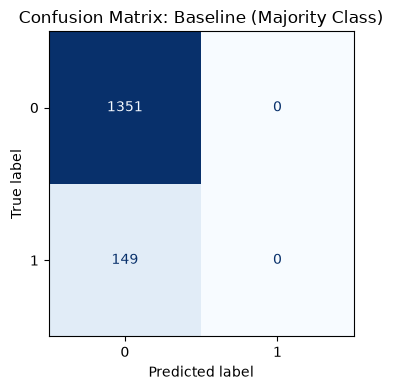

In [19]:
# dummy model always predicts the majority class
from sklearn.dummy import DummyClassifier

baseline = DummyClassifier(strategy="constant", constant=0)

baseline_metrics = train_and_evaluate(
    baseline,
    X_train,
    Y_train,
    X_test,
    Y_test,
    model_name="Baseline (Majority Class)"
)

# Train Initial Models

--- Naive Bayes 1 Evaluation ---
Accuracy:    0.8227
Precision:   0.3107
Recall:      0.6443 (Sensitivity)
Specificity: 0.8423
F1-Score:    0.4192
ROC AUC:     0.8071
------------------------------



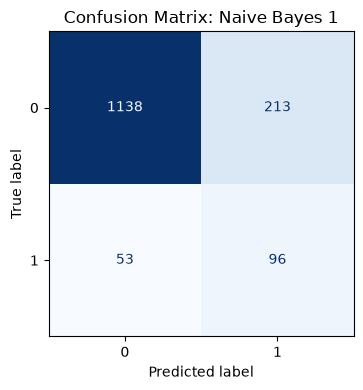

In [20]:
# Naive Bayes
from sklearn.naive_bayes import GaussianNB

nb_1 = GaussianNB()

nb_1_metrics = train_and_evaluate(
    nb_1,
    X_train_scaled,
    Y_train,
    X_test_scaled,
    Y_test,
    model_name="Naive Bayes 1"
)

# Compare Initial Models

In [21]:
# Compare all model results
model_results = [val for name, val in globals().items(
) if 'metrics' in name and isinstance(val, dict)]

# 2. Convert to DataFrame
results_df = pd.DataFrame(model_results)

# 3. Set the 'model' column as the index for better readability
results_df.set_index('model', inplace=True)

# 4. Display the table
results_df.sort_values(by='roc_auc', ascending=False). round(2)

,accuracy,precision,recall,specificity,f1_score,roc_auc
model,,,,,,
Naive Bayes 1,0.82,0.31,0.64,0.84,0.42,0.81
Baseline (Majority Class),0.90,0.00,0.00,1.00,0.00,0.50


# Explore Hyperparameters and Cost Matrices

# Compare all models